# Eksperimentu analīze

Notebook izmanto failu `results/experiment_results.csv`, ko saglabā modeļa notebook


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

ROOT = Path.cwd().parent if Path.cwd().name == "main" else Path.cwd()
RESULTS_PATH = ROOT / "results" / "experiment_results.csv"

plt.style.use("default")

## Dati


In [3]:
df = pd.read_csv(RESULTS_PATH)

number_cols = df.columns.drop("experiment")
df[number_cols] = df[number_cols].apply(pd.to_numeric, errors="coerce")

df["order"] = df["experiment"].str.extract(r"^(\d+)").astype(float)
df = df.sort_values("order").drop(columns="order").reset_index(drop=True)

df

,experiment,model_status,solutions,objective_value,mip_gap,runtime_seconds,solver_runtime_seconds,scheduled_lessons,unique_lessons,class_parallel_same_subject_slots,unfavorable_lessons,teacher_gaps,class_gaps,teacher_max_day_over,teacher_min_day_under,subject_spread_over,soft_score
0,0_only_strong,2.0,1.0,0.0,0.000000,335.054810,4.066,1231,1231,194,117,850,460,18,273,100,1800
1,1_balanced,9.0,7.0,1093.0,0.858188,3049.984705,2700.381,1231,1231,177,106,873,444,19,243,94,1760
2,2_unfavorable,9.0,8.0,2677.0,0.942099,3040.237769,2700.375,1231,1231,180,109,889,448,19,243,101,1790
3,3_teacher_gap,9.0,7.0,1975.0,0.921519,3050.142426,2700.370,1231,1231,180,100,851,432,19,248,94,1725
4,4_class_gap,9.0,7.0,1975.0,0.921519,3050.142426,2700.370,1231,1231,180,100,851,432,19,248,94,1725
5,5_subject_spread,9.0,7.0,1093.0,0.858188,3049.284280,2700.383,1231,1231,177,106,873,444,19,243,94,1760
6,6_teacher_min_day,9.0,10.0,3318.0,0.952080,3032.743042,2700.319,1231,1231,187,107,866,463,15,245,98,1779
7,7_best_long,9.0,10.0,1465.0,0.486689,29119.908936,28800.416,1231,1231,138,46,827,385,17,123,41,1422
8,8_best_long2,9.0,10.0,923.0,0.588299,43547.927239,43200.684,1231,1231,144,37,903,406,19,113,39,1498


## Labākais eksperiments


In [4]:
best = df.loc[df["soft_score"].idxmin()]

best[[
    "experiment",
    "soft_score",
    "objective_value",
    "mip_gap",
    "solver_runtime_seconds",
]]

experiment                7_best_long
soft_score                       1422
objective_value                1465.0
mip_gap                      0.486689
solver_runtime_seconds      28800.416
Name: 7, dtype: object

## Grafiki


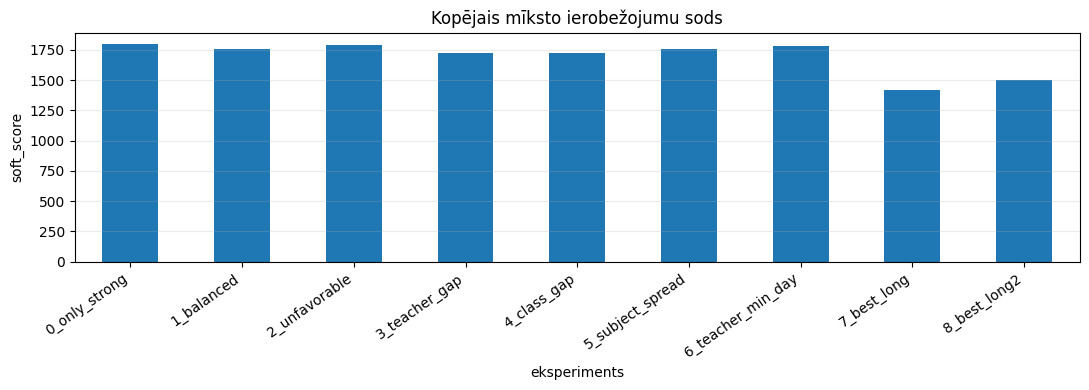

In [5]:
df.plot(x="experiment", y="soft_score", kind="bar", figsize=(11, 4), legend=False)
plt.title("Kopējais mīksto ierobežojumu sods")
plt.ylabel("soft_score")
plt.xlabel("eksperiments")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

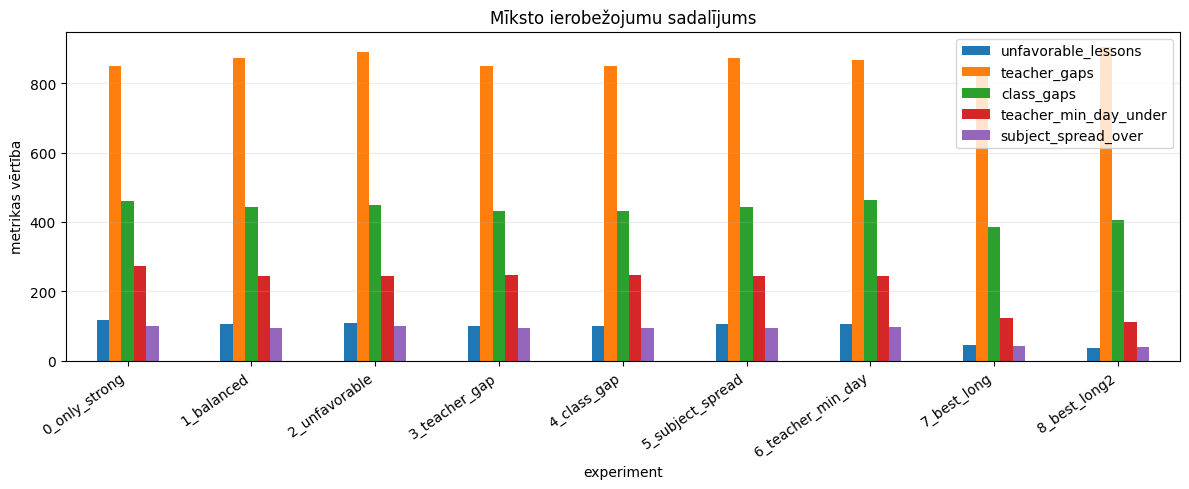

In [6]:
soft_metrics = [
    "unfavorable_lessons",
    "teacher_gaps",
    "class_gaps",
    "teacher_min_day_under",
    "subject_spread_over",
]

df.set_index("experiment")[soft_metrics].plot(kind="bar", figsize=(12, 5))
plt.title("Mīksto ierobežojumu sadalījums")
plt.ylabel("metrikas vērtība")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

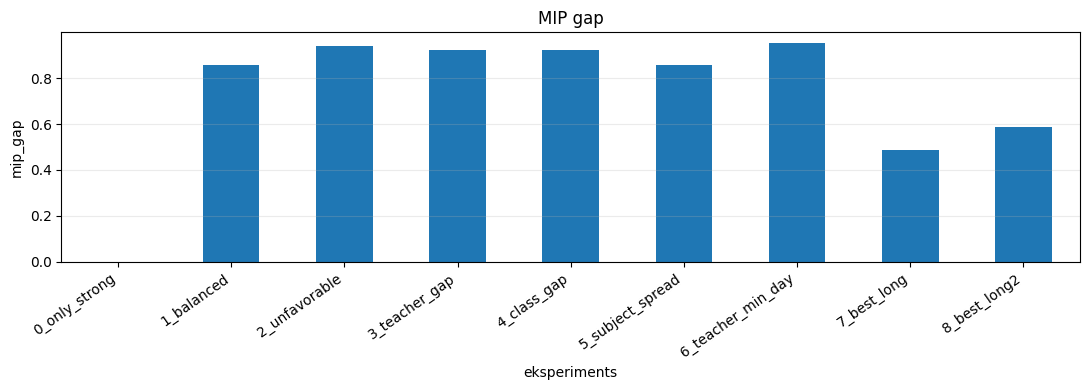

In [7]:
df.plot(x="experiment", y="mip_gap", kind="bar", figsize=(11, 4), legend=False)
plt.title("MIP gap")
plt.ylabel("mip_gap")
plt.xlabel("eksperiments")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

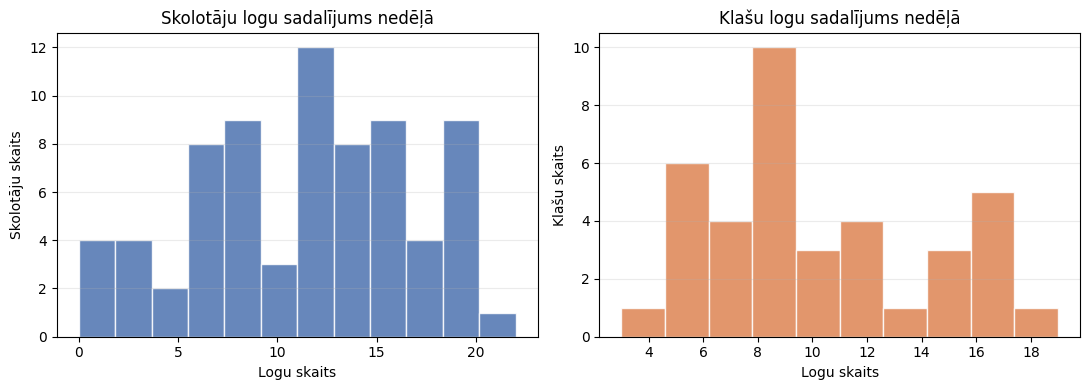

In [11]:
sched = pd.read_csv(ROOT / "results" / "experiments" / f"timetable_{best['experiment']}.csv")

def count_gaps(periods):
    periods = sorted(periods)
    return sum(
        period not in periods
        for period in range(periods[0], periods[-1] + 1)
    ) if periods else 0

teacher_periods = defaultdict(set)
class_periods = defaultdict(set)

for row in sched.itertuples(index=False):
    teacher_periods[(row.teacher, row.day)].add(row.period)
    for cls in str(row.participants).split("+"):
        class_periods[(cls, row.day)].add(row.period)

teacher_gaps = defaultdict(int)
for key, periods in teacher_periods.items():
    teacher_gaps[key[0]] += count_gaps(periods)

class_gaps = defaultdict(int)
for key, periods in class_periods.items():
    class_gaps[key[0]] += count_gaps(periods)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    teacher_gaps.values(),
    bins=12,
    color="#4C72B0",
    alpha=0.85,
    edgecolor="white",
)
axes[0].set_title("Skolotāju logu sadalījums nedēļā")
axes[0].set_xlabel("Logu skaits")
axes[0].set_ylabel("Skolotāju skaits")
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(
    class_gaps.values(),
    bins=10,
    color="#DD8452",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Klašu logu sadalījums nedēļā")
axes[1].set_xlabel("Logu skaits")
axes[1].set_ylabel("Klašu skaits")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## Kopsavilkuma tabula


In [9]:
df[[
    "experiment",
    "soft_score",
    "objective_value",
    "mip_gap",
    "solver_runtime_seconds",
    "unfavorable_lessons",
    "teacher_gaps",
    "class_gaps",
    "teacher_min_day_under",
    "subject_spread_over",
    "scheduled_lessons",
]]

,experiment,soft_score,objective_value,mip_gap,solver_runtime_seconds,unfavorable_lessons,teacher_gaps,class_gaps,teacher_min_day_under,subject_spread_over,scheduled_lessons
0,0_only_strong,1800,0.0,0.000000,4.066,117,850,460,273,100,1231
1,1_balanced,1760,1093.0,0.858188,2700.381,106,873,444,243,94,1231
2,2_unfavorable,1790,2677.0,0.942099,2700.375,109,889,448,243,101,1231
3,3_teacher_gap,1725,1975.0,0.921519,2700.370,100,851,432,248,94,1231
4,4_class_gap,1725,1975.0,0.921519,2700.370,100,851,432,248,94,1231
5,5_subject_spread,1760,1093.0,0.858188,2700.383,106,873,444,243,94,1231
6,6_teacher_min_day,1779,3318.0,0.952080,2700.319,107,866,463,245,98,1231
7,7_best_long,1422,1465.0,0.486689,28800.416,46,827,385,123,41,1231
8,8_best_long2,1498,923.0,0.588299,43200.684,37,903,406,113,39,1231
